# Technical Analysis of Historical Stock Data

## 1. Data Loading and Inspection

In [7]:
import pandas as pd

df = pd.read_csv('../data/yfinance/AAPL.csv')

df.head(20)

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800
5,2009-01-09,2.716589,2.800564,2.703393,2.795466,546845600
6,2009-01-12,2.659007,2.728886,2.625717,2.712990,617716400
7,2009-01-13,2.630514,2.691395,2.589726,2.646409,798397600
8,2009-01-14,2.559135,2.616717,2.540840,2.586427,1021664000
9,2009-01-15,2.500652,2.522846,2.400782,2.416377,1831634000


In [3]:
df.shape

(3774, 6)

In [4]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 2. Data Cleaning and Missing Value Analysis

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [10]:
df = df.sort_values('Date')

In [11]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 3. Technical Indicators (Simple Moving Average / SMA)

In [12]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

## 4. Visualizations

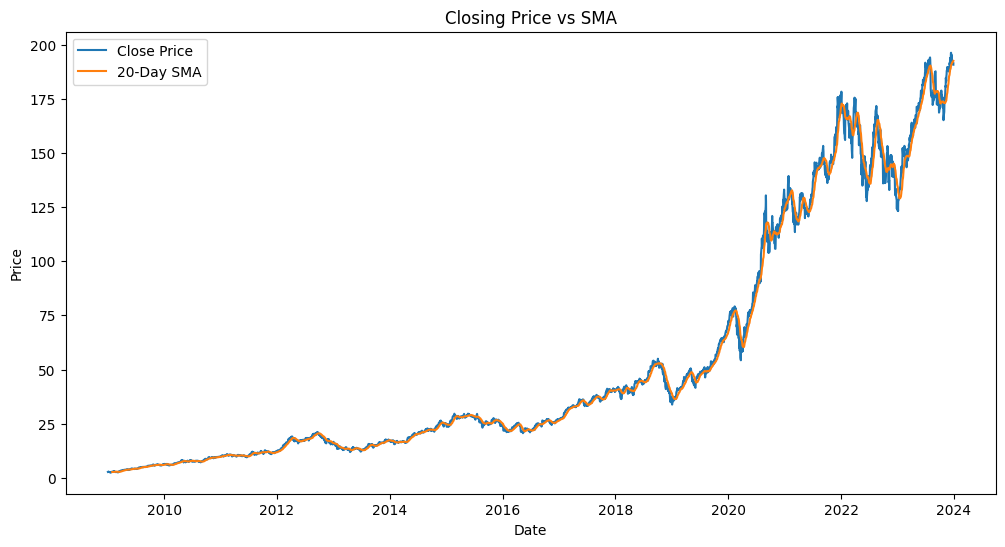

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='20-Day SMA')

plt.title('Closing Price vs SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [14]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

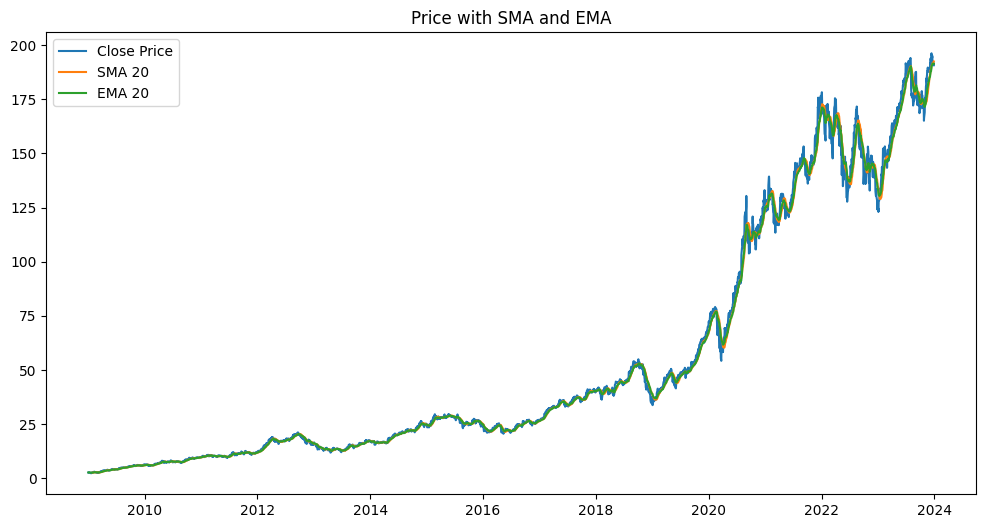

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title('Price with SMA and EMA')

plt.show()